In [1]:
import pandas as pd
import numpy as np
import wfdb
import ast
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# Constants
path = 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'
sampling_rate=100
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

COLORS = {
    'NORM': '#2196F3',
    'MI':   '#F44336',
    'STTC': '#FF9800',
    'CD':   '#9C27B0',
    'HYP':  '#4CAF50'
}

print('✅ Imports done')

✅ Imports done


In [3]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in tqdm(df.filename_lr)]
    else:
        data = [wfdb.rdsamp(path+f) for f in tqdm(df.filename_hr)]
    data = np.array([signal for signal, meta in data])
    return data

In [4]:
# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

print('data shpae:', X.shape)
Y[['scp_codes']]


  0%|                                                                                        | 0/21799 [00:00<?, ?it/s]

  0%|                                                                              | 18/21799 [00:00<02:02, 177.15it/s]

  0%|▏                                                                             | 38/21799 [00:00<01:55, 188.57it/s]

  0%|▏                                                                             | 57/21799 [00:00<01:55, 187.82it/s]

  0%|▎                                                                             | 78/21799 [00:00<01:51, 194.26it/s]

...

100%|██████████████████████████████████████████████████████████████████████████▉| 21773/21799 [01:33<00:00, 200.78it/s]

100%|██████████████████████████████████████████████████████████████████████████▉| 21794/21799 [01:33<00:00, 192.83it/s]

100%|███████████████████████████████████████████████████████████████████████████| 21799/21799 [01:33<00:00, 233.13it/s]

data shpae: (21799, 1000, 12)


,scp_codes
ecg_id,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}"
2,"{'NORM': 80.0, 'SBRAD': 0.0}"
3,"{'NORM': 100.0, 'SR': 0.0}"
4,"{'NORM': 100.0, 'SR': 0.0}"
5,"{'NORM': 100.0, 'SR': 0.0}"
...,...
21833,"{'NDT': 100.0, 'PVC': 100.0, 'VCLVH': 0.0, 'ST..."
21834,"{'NORM': 100.0, 'ABQRS': 0.0, 'SR': 0.0}"
21835,"{'ISCAS': 50.0, 'SR': 0.0}"


In [5]:
print(f'ECG signals shape : {X.shape}')   # (21837, 1000, 12) signals
print(f'Metadata shape    : {Y.shape}')    # (21837, 27) (age , sex ....)
print(f'Sampling rate     : {sampling_rate} Hz  →  {X.shape[1]/sampling_rate}s per record')

ECG signals shape : (21799, 1000, 12)
Metadata shape    : (21799, 27)
Sampling rate     : 100 Hz  →  10.0s per record


In [6]:
# Load SCP statements and filter to diagnostic only
agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]
print(f'Diagnostic SCP codes : {len(agg_df)}')

def aggregate_superclass(y_dic):
    return list(set(
        agg_df.loc[key].diagnostic_class
        for key in y_dic.keys()
        if key in agg_df.index
    ))

Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_superclass)
Y['n_superclass'] = Y['diagnostic_superclass'].apply(len)

# Records with NO superclass label → must be excluded
no_label = (Y['n_superclass'] == 0).sum()
print(f'\nRecords with no superclass label: {no_label} ({100*no_label/len(Y):.1f}%) → will be excluded')

Diagnostic SCP codes : 44



Records with no superclass label: 411 (1.9%) → will be excluded


In [7]:
# Filter out records with no label
Y_labeled = Y[Y['n_superclass'] > 0].copy()
X_labeled = X[Y['n_superclass'].values > 0]

print(f'After filtering: {len(Y_labeled)} records  (removed {len(Y) - len(Y_labeled)})')

# Build binary label matrix for 5 superclasses
for cls in SUPERCLASSES:
    Y_labeled[cls] = Y_labeled['diagnostic_superclass'].apply(lambda x: int(cls in x))

print('\nLabel matrix preview:')
Y_labeled[SUPERCLASSES].head()

After filtering: 21388 records  (removed 411)

Label matrix preview:


,NORM,MI,STTC,CD,HYP
ecg_id,,,,,
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
5,1,0,0,0,0


In [8]:
mask_labeled = Y['n_superclass'].values > 0
X = X[mask_labeled]
Y = Y[mask_labeled].copy()

for cls in SUPERCLASSES:
    Y[cls] = Y['diagnostic_superclass'].apply(lambda x: int(cls in x))

print(f'   Signal shape   : {X.shape}')
print('\Distribution per labels :')
for cls in SUPERCLASSES:
    n = Y[cls].sum()
    print(f'  {cls:4s}: {n:5d}  ({100*n/len(Y):.1f}%)')

   Signal shape   : (21388, 1000, 12)
\Distribution per labels :
  NORM:  9514  (44.5%)
  MI  :  5469  (25.6%)
  STTC:  5235  (24.5%)
  CD  :  4898  (22.9%)
  HYP :  2649  (12.4%)


In [9]:
META_FEATURES = ['age', 'sex', 'weight', 'nurse', 'site', 'device']

# Drop columns
COLS_TO_DROP = [
    'height',           # 68% missing
    'heart_axis',       # 38.9% missing, categorical 
    'infarction_stadium1', 'infarction_stadium2', 
    'baseline_drift', 'static_noise', 'burst_noise',
    'electrodes_problems', 'extra_beats', 'pacemaker', 
    'report',          
    'recording_date',  
    'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
    'filename_lr', 'filename_hr',
    'scp_codes', 'diagnostic_superclass', 'n_superclass',
    'patient_id'
]
COLS_TO_DROP = [c for c in COLS_TO_DROP if c in Y.columns]
Y_clean = Y.drop(columns=COLS_TO_DROP).copy()

# --- Imputation ---

# age : median (89 NaN = 0.4%)
age_median = Y_clean['age'].median()
Y_clean['age'] = Y_clean['age'].fillna(age_median)
print(f'age   → médiane imputée : {age_median:.1f} ans')

# weight : median (56.8% NaN — imputation )
weight_median = Y_clean['weight'].median()
Y_clean['weight'] = Y_clean['weight'].fillna(weight_median)
print(f'weight → médiane imputée : {weight_median:.1f} kg')

# nurse : mode
nurse_mode = Y_clean['nurse'].mode()[0]
Y_clean['nurse'] = Y_clean['nurse'].fillna(nurse_mode)
print(f'nurse  → mode imputé : {nurse_mode}')

# site : mode
site_mode = Y_clean['site'].mode()[0]
Y_clean['site'] = Y_clean['site'].fillna(site_mode)
print(f'site   → mode imputé : {site_mode}')

# device : label encoding
Y_clean['device'] = Y_clean['device'].astype('category').cat.codes
print(f'device → label encoded ({Y["device"].nunique()} devices → int)')

# Vérification
remaining_na = Y_clean[META_FEATURES].isnull().sum()
print(f'\n✅ NaN META_FEATURES :')
print(remaining_na)

age   → médiane imputée : 62.0 ans
weight → médiane imputée : 70.0 kg
nurse  → mode imputé : 0.0
site   → mode imputé : 0.0
device → label encoded (11 devices → int)

✅ NaN META_FEATURES :
age       0
sex       0
weight    0
nurse     0
site      0
device    0
dtype: int64


In [10]:
from scipy.signal import butter, filtfilt
import numpy as np

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=100, order=4):
    """
    Butterworth bandpass filter applied on all 12 leads.
    signal: (1000, 12)
    Returns: (1000, 12) filtered
    """
    nyq = 0.5 * fs
    low  = lowcut  / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal, axis=0)  # axis=0 = along time


def normalize_per_sample(signal):
    """
    Z-score normalization per sample per lead.
    signal: (1000, 12)
    """
    mean = signal.mean(axis=0, keepdims=True)  # (1, 12)
    std  = signal.std(axis=0, keepdims=True) + 1e-8
    return (signal - mean) / std


def preprocess_ecg_batch(X_batch, fs=100, apply_filter=True):
    """
    Apply the full preprocessing pipeline on a batch of ECG signals.
    X_batch: (N, 1000, 12)
    Returns: (N, 1000, 12) preprocessed
    """
    X_out = np.empty_like(X_batch, dtype=np.float32)
    for i in range(len(X_batch)):
        sig = X_batch[i].copy().astype(np.float64)
        if apply_filter:
            sig = bandpass_filter(sig, fs=fs)
        sig = normalize_per_sample(sig)
        X_out[i] = sig.astype(np.float32)
    return X_out


print('Preprocessing functions defined ✅')
print('Parameters:')
print('  - Bandpass filter : 0.5 Hz – 40 Hz  (Butterworth order 4)')
print('  - Normalization   : z-score per lead per sample')


Preprocessing functions defined ✅
Parameters:
  - Bandpass filter : 0.5 Hz – 40 Hz  (Butterworth order 4)
  - Normalization   : z-score per lead per sample


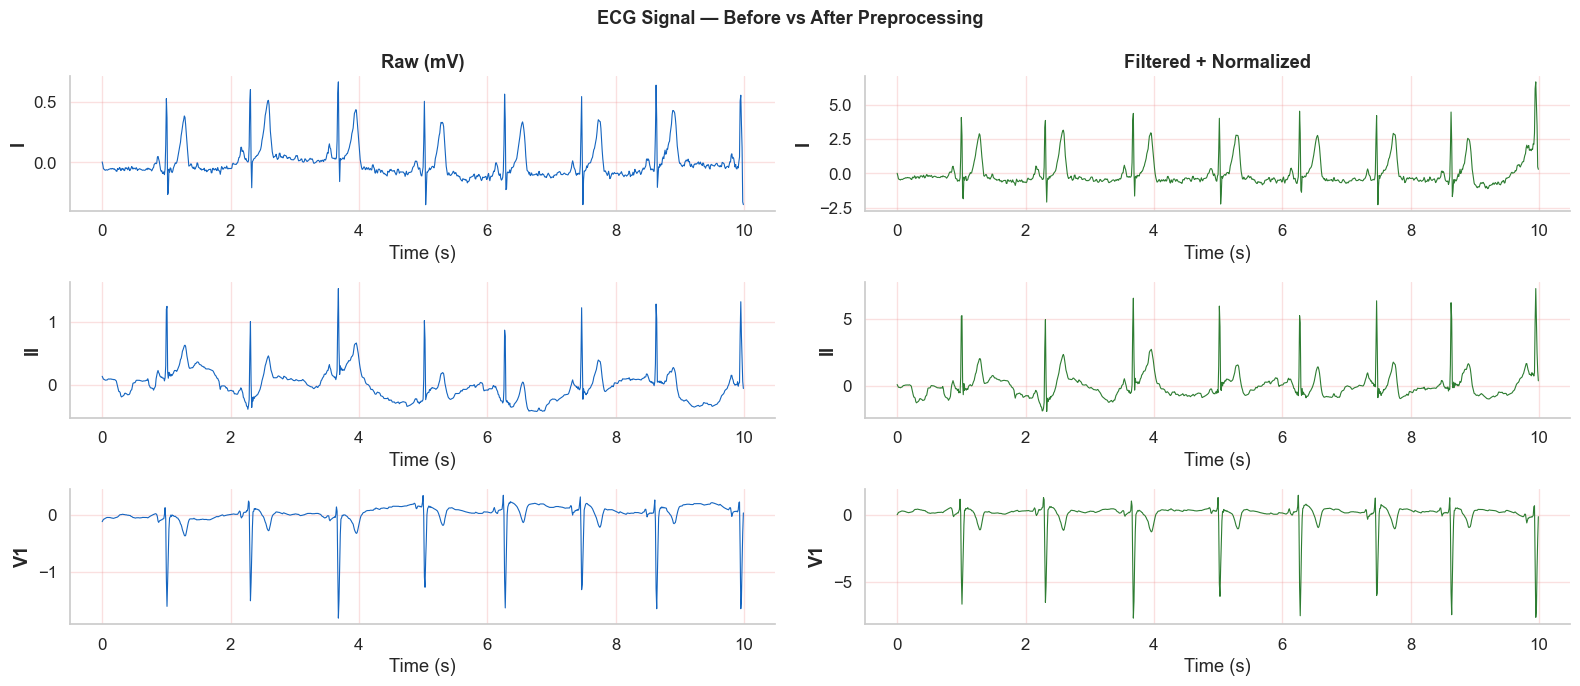

Raw   → mean=0.0019, std=0.2529
Proc  → mean=0.0000, std=1.0000


In [11]:
# Visual demonstration: before vs after preprocessing
sample_idx = 1 #np.where(Y['NORM'].values == 1)[0][0]  # one NORM record
raw_signal  = X[sample_idx]                          # (1000, 12)
proc_signal = preprocess_ecg_batch(X[sample_idx:sample_idx+1])[0]  # (1000, 12)

time = np.arange(1000) / sampling_rate
leads_to_show = [0, 1, 6]  # Lead I, II, V1

fig, axes = plt.subplots(len(leads_to_show), 2, figsize=(16, 7))
for row, lead_i in enumerate(leads_to_show):
    axes[row, 0].plot(time, raw_signal[:, lead_i], color='#1565C0', linewidth=0.8)
    axes[row, 0].set_ylabel(LEAD_NAMES[lead_i], fontweight='bold')
    axes[row, 0].set_title('Raw (mV)' if row == 0 else '', fontweight='bold')
    axes[row, 0].grid(True, alpha=0.3, color='#EF9A9A')

    axes[row, 1].plot(time, proc_signal[:, lead_i], color='#2E7D32', linewidth=0.8)
    axes[row, 1].set_ylabel(LEAD_NAMES[lead_i], fontweight='bold')
    axes[row, 1].set_title('Filtered + Normalized' if row == 0 else '', fontweight='bold')
    axes[row, 1].grid(True, alpha=0.3, color='#EF9A9A')

for ax in axes.flatten():
    ax.set_xlabel('Time (s)')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('ECG Signal — Before vs After Preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Raw   → mean={raw_signal.mean():.4f}, std={raw_signal.std():.4f}')
print(f'Proc  → mean={proc_signal.mean():.4f}, std={proc_signal.std():.4f}')


In [12]:
def get_split(Y_df, X_arr, folds):
    mask = np.isin(Y_df.strat_fold.values, folds)
    return X_arr[mask], Y_df[mask].copy()
    
x_train_raw, y_train = get_split(Y_clean, X, list(range(1,9)))
x_valid_raw, y_valid = get_split(Y_clean, X, [9])
x_test_raw, y_test = get_split(Y_clean, X,[10])

print(f'  Train : {len(y_train):5d} records  ({100*len(y_train)/len(Y_clean):.1f}%)')
print(f'  Valid : {len(y_valid):5d} records  ({100*len(y_valid)/len(Y_clean):.1f}%)')
print(f'  Test  : {len(y_test):5d} records  ({100*len(y_test)/len(Y_clean):.1f}%)')


  Train : 17084 records  (79.9%)
  Valid :  2146 records  (10.0%)
  Test  :  2158 records  (10.1%)


In [13]:
print('Preprocessing train split...')
x_train = preprocess_ecg_batch(x_train_raw)
print('Preprocessing valid split...')
x_valid = preprocess_ecg_batch(x_valid_raw)
print('Preprocessing test split...')
x_test  = preprocess_ecg_batch(x_test_raw)

print(f'\nx_train : {x_train.shape}  dtype={x_train.dtype}')
print(f'x_valid : {x_valid.shape}  dtype={x_valid.dtype}')
print(f'x_test  : {x_test.shape}   dtype={x_test.dtype}')

Preprocessing train split...


Preprocessing valid split...


Preprocessing test split...



x_train : (17084, 1000, 12)  dtype=float32
x_valid : (2146, 1000, 12)  dtype=float32
x_test  : (2158, 1000, 12)   dtype=float32


In [14]:
# Normalize numeric metadata (fit on train, apply on all)
NUM_META = ['age', 'weight']
meta_mean = y_train[NUM_META].mean()
meta_std  = y_train[NUM_META].std() + 1e-8
for df in [y_train, y_valid, y_test]:
    df[NUM_META] = (df[NUM_META] - meta_mean) / meta_std

print(f'✅ Train: {x_train.shape} | Valid: {x_valid.shape} | Test: {x_test.shape}')
print(f'   Meta features: {META_FEATURES}')


✅ Train: (17084, 1000, 12) | Valid: (2146, 1000, 12) | Test: (2158, 1000, 12)
   Meta features: ['age', 'sex', 'weight', 'nurse', 'site', 'device']


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
# Reproductibilité
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATH         = 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'
SAMPLING_RATE = 100
SUPERCLASSES  = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
META_FEATURES = ['age', 'sex', 'weight', 'nurse', 'site', 'device']
POS_WEIGHT    = torch.tensor([1.249, 2.899, 3.081, 3.374, 7.067])  # depuis EDA

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.11.0+cu130


In [17]:
class ECGDataset(Dataset):
    """
    Dataset multimodal : signal ECG (12 leads) + demographics.
    """
    def __init__(self, X_signals, Y_meta_df, superclasses=SUPERCLASSES, meta_features=META_FEATURES):
        # Signal : (N, 1000, 12) → transposé en (N, 12, 1000) pour Conv1D
        self.signals  = torch.tensor(X_signals.transpose(0, 2, 1), dtype=torch.float32)
        self.meta     = torch.tensor(Y_meta_df[meta_features].values, dtype=torch.float32)
        self.labels   = torch.tensor(Y_meta_df[superclasses].values, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.signals[idx], self.meta[idx], self.labels[idx]


# DataLoaders
BATCH_SIZE = 64

train_ds = ECGDataset(x_train, y_train)
valid_ds = ECGDataset(x_valid, y_valid)
test_ds  = ECGDataset(x_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Sanity check
sig, meta, lab = next(iter(train_loader))
print(f'Signal batch : {sig.shape}   → (batch, 12 leads, 1000 timesteps)')
print(f'Meta batch   : {meta.shape}  → (batch, 6 features)')
print(f'Label batch  : {lab.shape}   → (batch, 5 classes)')

Signal batch : torch.Size([64, 12, 1000])   → (batch, 12 leads, 1000 timesteps)
Meta batch   : torch.Size([64, 6])  → (batch, 6 features)
Label batch  : torch.Size([64, 5])   → (batch, 5 classes)


In [18]:

#Augmentation the data

class ECGSSLData(torch.utils.data.Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X.transpose(0, 2, 1), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def augment(self, x):
        x = x.clone()
    
        # 1. Slight noise (always)
        x = x + 0.01 * torch.randn_like(x)
    
        # 2. Time shift (strong but consistent)
        shift = torch.randint(-150, 150, (1,))
        x = torch.roll(x, shifts=int(shift), dims=1)
    
        # 3. Scaling
        scale = torch.rand(1) * 0.4 + 0.8
        x = x * scale
    
        # 4. ONE strong transformation (not many)
        if torch.rand(1) < 0.5:
            # masking
            length = torch.randint(150, 400, (1,))
            start = torch.randint(0, 1000 - length, (1,))
            x[:, start:start+length] = 0
        else:
            # lead dropout
            lead = torch.randint(0, 12, (1,))
            x[lead] = 0
    
        return x

    def __getitem__(self, idx):
        x = self.X[idx]

        x1 = self.augment(x.clone())
        x2 = self.augment(x.clone())

        return x1, x2

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ─────────────────────────────────────────────
# Depthwise Separable Conv
# ─────────────────────────────────────────────
class DepthwiseSepConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, padding='same'):
        super().__init__()
        self.dw = nn.Conv1d(in_ch, in_ch, kernel_size,
                            padding=padding, groups=in_ch, bias=False)
        self.pw = nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        return F.relu(self.bn(self.pw(self.dw(x))))


# ─────────────────────────────────────────────
# Residual Block
# ─────────────────────────────────────────────
class ResBlock1d(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        self.conv1 = DepthwiseSepConv1d(channels, channels, kernel_size)
        self.conv2 = DepthwiseSepConv1d(channels, channels, kernel_size)
        self.bn = nn.BatchNorm1d(channels)

    def forward(self, x):
        return F.relu(self.bn(x + self.conv2(self.conv1(x))))


# ─────────────────────────────────────────────
# SSL Encoder (NO META, NO CLASSIFIER)
# ─────────────────────────────────────────────
class ECGEncoder(nn.Module):
    def __init__(self, n_leads=12, base_channels=64, emb_dim=256):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, base_channels, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.block1 = nn.Sequential(
            ResBlock1d(base_channels, kernel_size=7),
            nn.MaxPool1d(2)
        )

        self.trans1 = nn.Sequential(
            nn.Conv1d(base_channels, base_channels * 2, 1, bias=False),
            nn.BatchNorm1d(base_channels * 2),
            nn.ReLU()
        )

        self.block2 = nn.Sequential(
            ResBlock1d(base_channels * 2, kernel_size=5),
            nn.MaxPool1d(2)
        )

        self.trans2 = nn.Sequential(
            nn.Conv1d(base_channels * 2, base_channels * 4, 1, bias=False),
            nn.BatchNorm1d(base_channels * 4),
            nn.ReLU()
        )

        self.block3 = nn.Sequential(
            ResBlock1d(base_channels * 4, kernel_size=3),
            nn.MaxPool1d(2)
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.out_dim = base_channels * 4  # 256

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (B, 12, 1000)
        x = self.stem(x)
        x = self.block1(x)
        x = self.trans1(x)
        x = self.block2(x)
        x = self.trans2(x)
        x = self.block3(x)

        x = self.gap(x).squeeze(-1)  # (B, 256)
        return x

In [20]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim=256, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim)
        )

    def forward(self, x):
        return self.net(x)

In [21]:
class ECGSimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = ProjectionHead(encoder.out_dim, 128)

    def forward(self, x):
        h = self.encoder(x)      # (B, 256)
        z = self.projector(h)    # (B, 128)

        # Normalize (IMPORTANT for contrastive learning)
        z = F.normalize(z, dim=1)

        return h, z

In [22]:
class ECGClassifier(nn.Module):
    def __init__(self, encoder, n_meta=6, n_classes=5, dropout=0.3):
        super().__init__()

        self.encoder = encoder  # pretrained

        self.meta_mlp = nn.Sequential(
            nn.Linear(n_meta, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 32),
            nn.ReLU()
        )

        fusion_dim = encoder.out_dim + 32

        self.head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, signal, meta):
        with torch.no_grad():  # freeze encoder
            x = self.encoder(signal)

        m = self.meta_mlp(meta)
        x = torch.cat([x, m], dim=1)

        return self.head(x)

In [23]:
def nt_xent_loss(z1, z2, temperature=0.2):
    B = z1.size(0)

    z = torch.cat([z1, z2], dim=0)  # (2B, D)
    z = F.normalize(z, dim=1)

    sim = torch.matmul(z, z.T) / temperature  # (2B, 2B)

    # remove self-similarity
    mask = torch.eye(2*B, dtype=torch.bool).to(z.device)
    sim = sim.masked_fill(mask, -1e9)

    # correct labels: positive pairs
    labels = torch.arange(B).to(z.device)
    labels = torch.cat([labels + B, labels])  # match pairs

    return F.cross_entropy(sim, labels)

In [24]:
#DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ssl_dataset = ECGSSLData(x_train)
ssl_loader = DataLoader(ssl_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=True)

model = ECGSimCLR(ECGEncoder()).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [26]:
x1, x2 = next(iter(ssl_loader))
x1 = x1.to(DEVICE)

h, z = model(x1)

print(h.shape)  # should be (B, 256)
print(z.shape)  # should be (B, 128)

torch.Size([128, 256])
torch.Size([128, 128])


In [127]:
from tqdm import tqdm

for epoch in tqdm(range(10)):
    model.train()
    total_loss = 0

    for x1, x2 in ssl_loader:
        x1, x2 = x1.to(DEVICE), x2.to(DEVICE)

        _, z1 = model(x1)
        _, z2 = model(x2)

        loss = nt_xent_loss(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: {total_loss / len(ssl_loader):.4f}")

  0%|                                                                           | 0/10 [00:00<?, ?it/s]

 10%|██████▋                                                            | 1/10 [00:42<06:20, 42.22s/it]

Epoch 0: 1.9370


 20%|█████████████▍                                                     | 2/10 [01:19<05:13, 39.17s/it]

Epoch 1: 1.4479


...

 90%|████████████████████████████████████████████████████████████▎      | 9/10 [05:39<00:36, 36.67s/it]

Epoch 8: 1.2186


100%|██████████████████████████████████████████████████████████████████| 10/10 [06:16<00:00, 36.64s/it]

100%|██████████████████████████████████████████████████████████████████| 10/10 [06:16<00:00, 37.63s/it]

Epoch 9: 1.2092


In [128]:
torch.save(model.encoder.state_dict(), "ecg_encoder_ssl.pth")

In [25]:
import torch
print(torch.cuda.is_available())

True


In [26]:
# ✅ Fix optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# ✅ Reduce augmentations
# gentler noise, smaller shifts, shorter masks

# ✅ Ensure proper pairing in NT-Xent

# ✅ Optional: print grad norms
for name, p in model.named_parameters():
    if p.grad is not None:
        print(name, p.grad.norm())

# ✅ Check that the temperature and normalization are applied correctly



In [27]:
encoder = ECGEncoder()
encoder.load_state_dict(torch.load("ecg_encoder_ssl.pth"))
encoder = encoder.to(DEVICE)

In [28]:
for p in encoder.parameters():
    p.requires_grad = False

In [29]:
model = ECGClassifier(encoder).to(DEVICE)

In [30]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print(f'Total estimate  : ~{total_params * 4 / 1e6:.2f} MB (float32)')

Total params    : 270,725
Trainable params: 38,917
Total estimate  : ~1.08 MB (float32)


In [31]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 5

for epoch in tqdm(range(10)):
    model.train()
    total_loss = 0

    for signal, meta, labels in train_loader:
        signal = signal.to(DEVICE)
        meta = meta.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(signal, meta)  # (B, 5)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch}: Train Loss = {avg_loss:.4f}")

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

 10%|████████▎                                                                          | 1/10 [00:04<00:36,  4.07s/it]

Epoch 0: Train Loss = 0.3811


 20%|████████████████▌                                                                  | 2/10 [00:07<00:28,  3.58s/it]

Epoch 1: Train Loss = 0.3367


...

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [00:32<00:03,  3.50s/it]

Epoch 8: Train Loss = 0.3095


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:36<00:00,  3.88s/it]

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:36<00:00,  3.68s/it]

Epoch 9: Train Loss = 0.3075


In [32]:
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for signal, meta, labels in valid_loader:
            signal = signal.to(DEVICE)
            meta = meta.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(signal, meta)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(valid_loader)
    print(f"Epoch {epoch}: Val Loss = {val_loss:.4f}")

Epoch 9: Val Loss = 0.3170


In [33]:
import numpy as np
from sklearn.metrics import roc_auc_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for signal, meta, labels in valid_loader:
        signal = signal.to(DEVICE)
        meta = meta.to(DEVICE)

        outputs = model(signal, meta)

        probs = torch.sigmoid(outputs).cpu().numpy()

        y_pred.append(probs)
        y_true.append(labels.numpy())

# Stack
y_pred = np.vstack(y_pred)
y_true = np.vstack(y_true)

# Macro AUC
auc = roc_auc_score(y_true, y_pred, average='macro')

print("Validation AUC:", auc)

Validation AUC: 0.8878217279508661


In [ ]:
class ECGSSLWithLabels(Dataset):
    def __init__(self, X, Y):
        # X: (N, T, 12) → convert to (N, 12, T)
        self.X = torch.tensor(X.transpose(0, 2, 1), dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def augment(self, x):
        x = x.clone()

        # noise
        x = x + 0.01 * torch.randn_like(x)

        # time shift
        shift = torch.randint(-150, 150, (1,))
        x = torch.roll(x, shifts=int(shift), dims=1)

        # scaling
        scale = torch.rand(1) * 0.4 + 0.8
        x = x * scale

        # one strong transform
        if torch.rand(1) < 0.5:
            length = torch.randint(150, 400, (1,))
            start = torch.randint(0, x.shape[1] - length, (1,))
            x[:, start:start+length] = 0
        else:
            lead = torch.randint(0, 12, (1,))
            x[lead] = 0

        return x

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]

        x1 = self.augment(x)
        x2 = self.augment(x)

        return x1, x2, y

In [104]:
class SupaCon_ProjectionHead(nn.Module):
    def __init__(self, in_dim=256, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(),
            nn.Linear(in_dim, proj_dim)
        )

    def forward(self, x):
        projections = self.net(x)
        # This is the "Silver Bullet" fix:
        projections = F.normalize(projections, p=2, dim=1) 
        return projections

In [105]:
class ECGSupConModel(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.projector = SupaCon_ProjectionHead(encoder.out_dim, 128)

    def forward(self, x):
        h = self.encoder(x)        # (B, 256)
        z = self.projector(h)      # (B, 128)
        z = F.normalize(z, dim=1)  # IMPORTANT
        return h, z

In [106]:
def label_similarity(y):
    """
    y: (B, C) multi-hot
    returns: (B, B)
    """
    y = y.float()
    intersection = torch.matmul(y, y.T)

    y_sum = y.sum(dim=1, keepdim=True)
    union = y_sum + y_sum.T - intersection + 1e-8

    sim = intersection / union
    return sim

In [107]:
def multilabel_supcon_loss(z, y, temperature=0.2):
    B = y.size(0)

    y = torch.cat([y, y], dim=0)  # (2B, C)

    # label similarity
    sim_labels = label_similarity(y)  # (2B, 2B)
    # embedding similarity
    sim = torch.matmul(z, z.T) / temperature

    # mask self
    mask = torch.eye(2*B, dtype=torch.bool).to(z.device)
    sim = sim.masked_fill(mask, -1e4)

    # remove self from label sim
    sim_labels = sim_labels.masked_fill(mask, 0)

    # 🔥 FIX 1: clamp minimum
    row_sum = sim_labels.sum(dim=1, keepdim=True)

    # 🔥 FIX 2: avoid divide by zero
    sim_labels = sim_labels / (row_sum + 1e-6)

    # 🔥 FIX 3: ignore rows with no positives
    valid = (row_sum > 1e-6).float()

    log_prob = F.log_softmax(sim, dim=1)

    loss = -(sim_labels * log_prob).sum(dim=1)

    # apply mask
    loss = (loss * valid.squeeze()).sum() / (valid.sum() + 1e-6)

    return loss

In [108]:
y_train_supacon = y_train[['NORM', 'MI', 'STTC', 'CD', 'HYP']]

In [109]:
x_train_supacon = x_train

In [110]:
indices = np.lexsort(y_train_supacon.to_numpy().T)


In [111]:
x_train_supacon = x_train_supacon[indices]


In [112]:
y_train_supacon = y_train_supacon.iloc[indices].reset_index(drop=True)

In [115]:
ssl_dataset = ECGSSLWithLabels(x_train_supacon, y_train_supacon.to_numpy())

ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [116]:
encoder = ECGEncoder().to(DEVICE)
model = ECGSupConModel(encoder).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

EPOCHS = 10

for epoch in tqdm(range(EPOCHS)):
    model.train()
    total_loss = 0

    for x1, x2, labels in ssl_loader:
        x1 = x1.to(DEVICE)
        x2 = x2.to(DEVICE)
        labels = labels.to(DEVICE)

        _, z1 = model(x1)
        _, z2 = model(x2)

        z = torch.cat([z1, z2], dim=0)

        loss = multilabel_supcon_loss(z, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
    print("z max:", z.max().item(), "z min:", z.min().item())
    print(f"Epoch {epoch}: {total_loss / len(ssl_loader):.4f}")

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

 10%|████████▎                                                                          | 1/10 [01:28<13:12, 88.05s/it]

z max: 0.3611795902252197 z min: -0.2617581784725189
Epoch 0: 6.1178


 20%|████████████████▌                                                                  | 2/10 [02:47<11:03, 82.97s/it]

z max: 0.2973930239677429 z min: -0.2673257291316986
Epoch 1: 6.0194


...

 90%|█████████████████████████████████████████████████████████████████████████▊        | 9/10 [16:10<02:03, 123.72s/it]

z max: 0.2930494546890259 z min: -0.29771921038627625
Epoch 8: 5.9180


100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [19:00<00:00, 137.94s/it]

100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [19:00<00:00, 114.04s/it]

z max: 0.29343244433403015 z min: -0.3060757517814636
Epoch 9: 5.9114


In [ ]:
torch.save(model.encoder.state_dict(), "ecg_encoder_supcon.pth")